## Nyquist curves for different parameter regimes

<>:29: SyntaxWarning: invalid escape sequence '\G'
<>:30: SyntaxWarning: invalid escape sequence '\G'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\G'
<>:29: SyntaxWarning: invalid escape sequence '\G'
<>:30: SyntaxWarning: invalid escape sequence '\G'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipython-input-3232113769.py:29: SyntaxWarning: invalid escape sequence '\G'
  ax1.set_xlabel('Re($\Gamma_k(\omega)$)')
/tmp/ipython-input-3232113769.py:30: SyntaxWarning: invalid escape sequence '\G'
  ax1.set_ylabel('Im($\Gamma_k(\omega)$)')
/tmp/ipython-input-3232113769.py:39: SyntaxWarning: invalid escape sequence '\o'
  ax2.set_xlabel('Frequency $\omega$')
/tmp/ipython-input-3232113769.py:40: SyntaxWarning: invalid escape sequence '\G'
  ax2.set_ylabel('|$\Gamma_k(\omega)$|')


Encirclements: -63.0
Stable: False
Critical delays: []


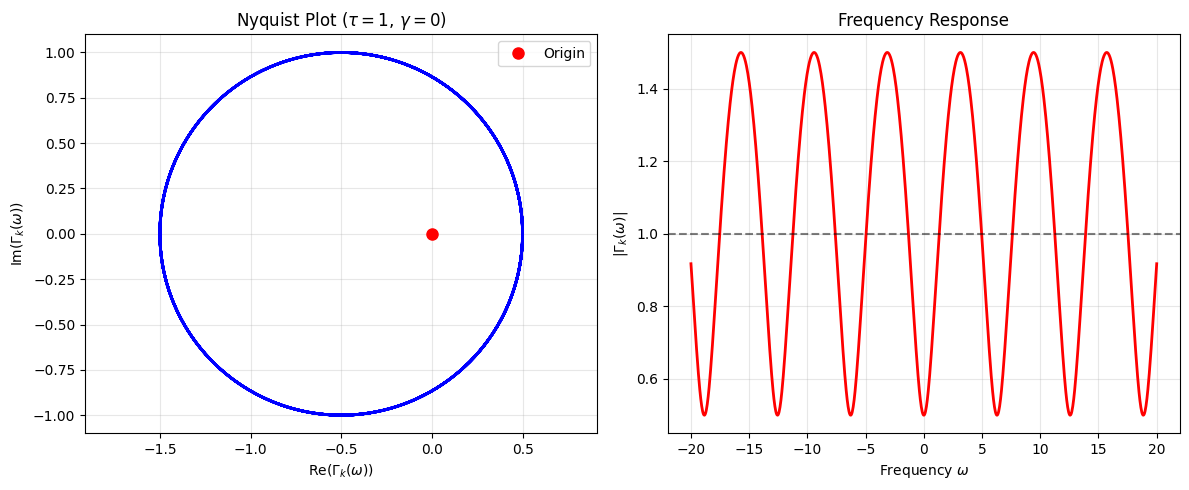

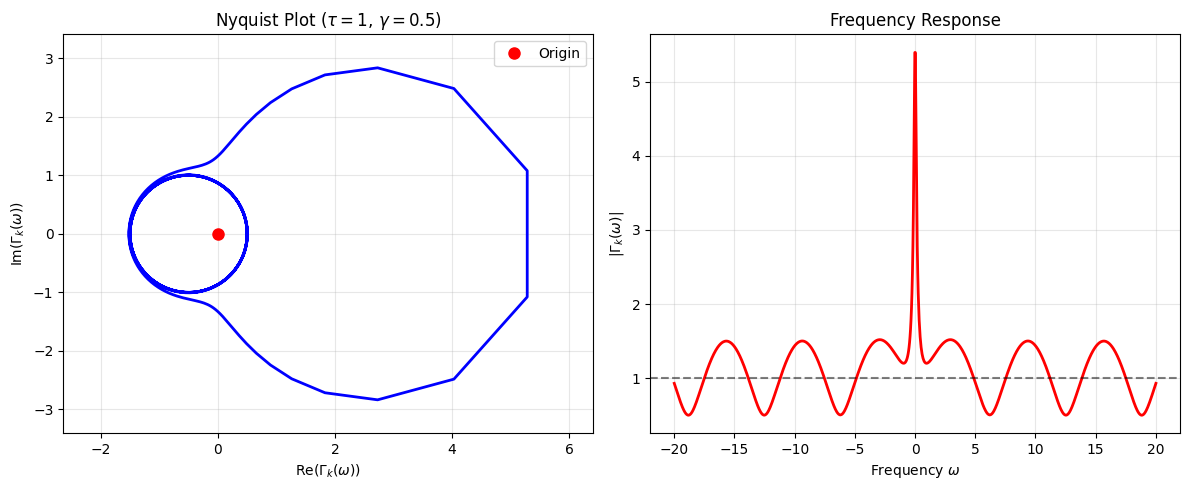

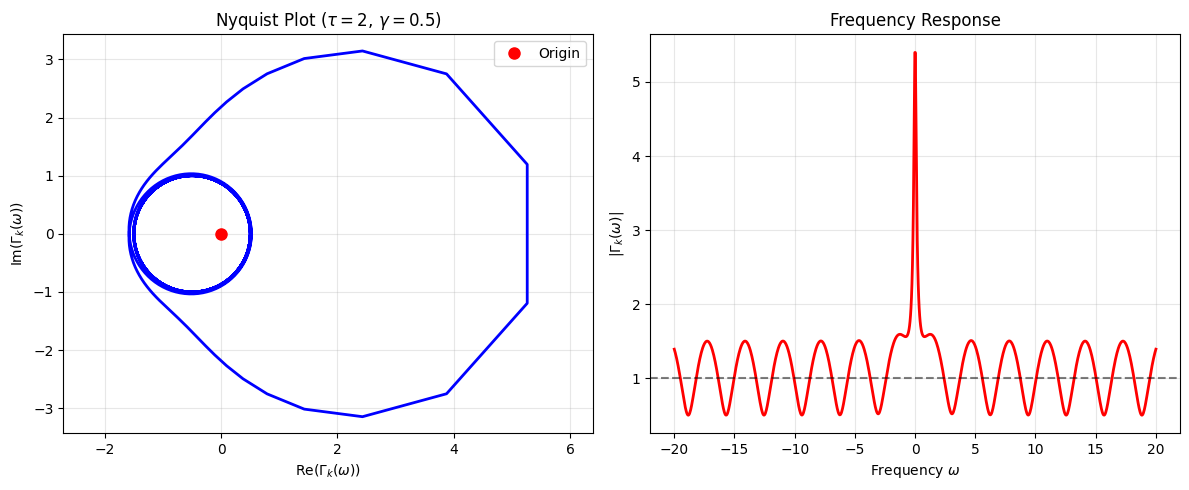

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def nyquist_curve(lam=-0.5, beta=1.0, gamma=0.5, alpha=0.1, tau=1.0,
                  omega_range=(-20, 20), n_points=1000):
    """
    Compute and plot Nyquist curve for neural field stability criterion.

    Parameters:
    lam, beta, gamma, alpha, tau: System parameters
    omega_range: Tuple (omega_min, omega_max)
    n_points: Number of frequency points
    """
    # Frequency array
    omega = np.linspace(omega_range[0], omega_range[1], n_points)

    # Compute Nyquist curve
    plastic_term = beta + gamma / (1j*omega + alpha)
    Gamma = lam + plastic_term * np.exp(-1j*omega*tau)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Nyquist plot
    ax1 = axes[0]
    ax1.plot(np.real(Gamma), np.imag(Gamma), 'b-', linewidth=2)
    ax1.plot(0, 0, 'ro', markersize=8, label='Origin')
    ax1.set_xlabel('Re($\Gamma_k(\omega)$)')
    ax1.set_ylabel('Im($\Gamma_k(\omega)$)')
    ax1.set_title(f'Nyquist Plot ($\\tau={tau}$, $\\gamma={gamma}$)')
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')
    ax1.legend()

    # Frequency response magnitude
    ax2 = axes[1]
    ax2.plot(omega, np.abs(Gamma), 'r-', linewidth=2)
    ax2.set_xlabel('Frequency $\omega$')
    ax2.set_ylabel('|$\Gamma_k(\omega)$|')
    ax2.set_title('Frequency Response')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1, color='k', linestyle='--', alpha=0.5)

    plt.tight_layout()
    return fig, Gamma

def stability_analysis(lam=-0.5, beta=1.0, gamma=0.5, alpha=0.1, tau=1.0):
    """
    Perform complete stability analysis using Nyquist criterion.
    """
    # Compute encirclements
    omega = np.linspace(-100, 100, 10000)
    plastic_term = beta + gamma / (1j*omega + alpha)
    Gamma = lam + plastic_term * np.exp(-1j*omega*tau)

    # Count encirclements of origin
    angle = np.unwrap(np.angle(Gamma))
    encirclements = np.round((angle[-1] - angle[0]) / (2*np.pi))

    # Compute critical delays for stability switches
    # Solve |beta + gamma/(iω+α)| = |λ| for ω
    # For given parameters, this requires numerical solution
    from scipy.optimize import fsolve

    def equation(omega_val):
        return np.abs(beta + gamma/(1j*omega_val + alpha)) - np.abs(lam)

    # Find ω where magnitude condition holds
    omega_candidates = np.linspace(0, 10, 100)
    magnitudes = np.abs(beta + gamma/(1j*omega_candidates + alpha))
    idx = np.where(np.abs(magnitudes - np.abs(lam)) < 0.1)[0]

    critical_taus = []
    if len(idx) > 0:
        for i in idx:
            omega_c = omega_candidates[i]
            # Compute phase condition
            phase = np.angle(beta + gamma/(1j*omega_c + alpha))
            # Critical taus satisfy: -ωτ + phase = π mod 2π
            tau_c = (phase - np.pi + 2*np.pi*np.arange(5)) / (-omega_c)
            critical_taus.extend(tau_c[tau_c > 0])

    return {
        'encirclements': encirclements,
        'stable': encirclements == 0,
        'critical_delays': sorted(critical_taus)[:5] if critical_taus else []
    }

# Example usage
if __name__ == "__main__":
    # Case 1: Without plasticity
    fig1, Gamma1 = nyquist_curve(gamma=0, tau=1)

    # Case 2: With plasticity
    fig2, Gamma2 = nyquist_curve(gamma=0.5, tau=1)

    # Case 3: With plasticity and larger delay
    fig3, Gamma3 = nyquist_curve(gamma=0.5, tau=2)

    # Stability analysis
    result = stability_analysis(tau=2)
    print(f"Encirclements: {result['encirclements']}")
    print(f"Stable: {result['stable']}")
    print(f"Critical delays: {result['critical_delays']}")

    plt.show()

In [5]:
# Jupyter notebook interactive widget
import ipywidgets as widgets
from IPython.display import display

@widgets.interact
def interactive_nyquist(
    lam=(-1.0, 0.0, 0.1),
    beta=(0.0, 2.0, 0.1),
    gamma=(0.0, 1.0, 0.1),
    alpha=(0.05, 1.0, 0.05),
    tau=(0.0, 5.0, 0.1)
):
    fig, _ = nyquist_curve(lam=lam, beta=beta,
                          gamma=gamma, alpha=alpha, tau=tau)
    plt.show()

interactive(children=(FloatSlider(value=-0.5, description='lam', max=0.0, min=-1.0), FloatSlider(value=1.0, de…

## Stability Switching Analysis

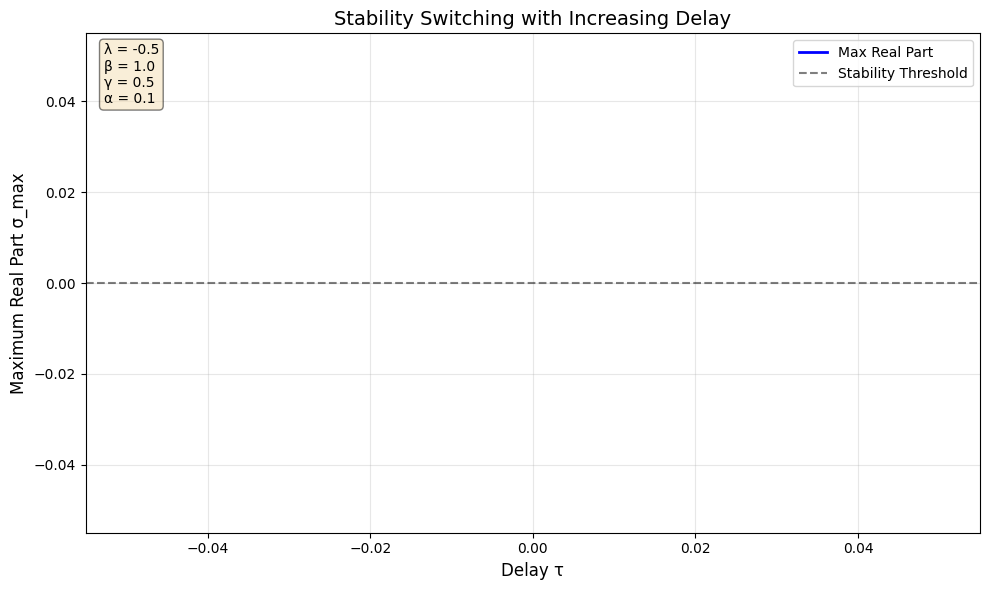

Critical delays found: []


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize_scalar

def characteristic_eq(s, lam, beta, gamma, alpha, tau):
    """Characteristic equation for neural field with delayed plasticity."""
    return s - lam - (beta + gamma/(s + alpha)) * np.exp(-s*tau)

def max_real_part(lam=-0.5, beta=1.0, gamma=0.5, alpha=0.1, tau=1.0,
                  search_range=(-5, 5)):
    """
    Find the maximum real part of roots for given parameters.

    Uses a grid search and refinement to find roots of the
    transcendental characteristic equation.
    """
    max_real = -np.inf
    found_roots = []

    # Grid search in complex plane
    for real in np.linspace(search_range[0], search_range[1], 100):
        for imag in np.linspace(-10, 10, 200):
            guess = complex(real, imag)
            try:
                # Use fsolve to find nearby root
                root = fsolve(
                    lambda z: characteristic_eq(z, lam, beta, gamma, alpha, tau),
                    guess,
                    maxfev=1000
                )[0]
                # Check if root is valid
                if abs(characteristic_eq(root, lam, beta, gamma, alpha, tau)) < 1e-6:
                    found_roots.append(root)
                    max_real = max(max_real, root.real)
            except:
                continue

    return max_real, found_roots

def compute_stability_switching(tau_range=(0, 10), n_points=200):
    """Compute stability switching curve."""
    taus = np.linspace(tau_range[0], tau_range[1], n_points)
    max_reals = []

    for tau in taus:
        max_real, _ = max_real_part(tau=tau)
        max_reals.append(max_real)

    return taus, max_reals

def find_critical_delays(tau_range=(0, 10), n_points=1000):
    """Find critical delays where stability changes."""
    taus = np.linspace(tau_range[0], tau_range[1], n_points)
    max_reals = []

    for tau in taus:
        max_real, _ = max_real_part(tau=tau)
        max_reals.append(max_real)

    max_reals = np.array(max_reals)

    # Find where max_real crosses zero
    critical_delays = []
    for i in range(len(taus)-1):
        if max_reals[i] * max_reals[i+1] <= 0:
            # Linear interpolation for critical delay
            tau_crit = taus[i] - max_reals[i] * (taus[i+1] - taus[i]) / \
                      (max_reals[i+1] - max_reals[i])
            critical_delays.append(tau_crit)

    return critical_delays

# Generate and plot stability switching
if __name__ == "__main__":
    # Compute stability switching curve
    taus, max_reals = compute_stability_switching(tau_range=(0, 10), n_points=500)

    # Find critical delays
    critical_delays = find_critical_delays(tau_range=(0, 10), n_points=1000)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(taus, max_reals, 'b-', linewidth=2, label='Max Real Part')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='Stability Threshold')

    # Fill stable regions
    for i in range(len(taus)-1):
        if max_reals[i] < 0:
            plt.fill_between(taus[i:i+2], max_reals[i:i+2], 0,
                           color='green', alpha=0.3)

    # Mark critical delays
    for tau_crit in critical_delays:
        plt.axvline(x=tau_crit, color='red', linestyle='--', alpha=0.7)
        plt.text(tau_crit, 0.28, f'τ={tau_crit:.2f}',
                rotation=90, va='bottom', ha='right')

    plt.xlabel('Delay τ', fontsize=12)
    plt.ylabel('Maximum Real Part σ_max', fontsize=12)
    plt.title('Stability Switching with Increasing Delay', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Add parameter information
    param_text = f'λ = -0.5\nβ = 1.0\nγ = 0.5\nα = 0.1'
    plt.text(0.02, 0.98, param_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    print(f"Critical delays found: {critical_delays}")


In [9]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np # Import numpy for array operations

@widgets.interact(
    lam=(-1.0, 0.0, 0.1),
    beta=(0.0, 2.0, 0.1),
    gamma=(0.0, 1.0, 0.1),
    alpha=(0.05, 1.0, 0.05),
    tau_max=(5, 20, 1)
)
def interactive_stability(lam=-0.5, beta=1.0, gamma=0.5, alpha=0.1, tau_max=10):
    taus, max_reals = compute_stability_switching(tau_range=(0, tau_max), n_points=200)
    max_reals = np.array(max_reals) # Convert max_reals to a NumPy array

    plt.figure(figsize=(10, 6))
    plt.plot(taus, max_reals, 'b-', linewidth=2)
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.fill_between(taus, max_reals, 0, where=(max_reals<0), color='green', alpha=0.3)
    plt.xlabel('Delay τ')
    plt.ylabel('Max Real Part')
    plt.title(f'Stability Switching (λ={lam}, β={beta}, γ={gamma}, α={alpha})')
    plt.grid(True, alpha=0.3)
    plt.show()

interactive(children=(FloatSlider(value=-0.5, description='lam', max=0.0, min=-1.0), FloatSlider(value=1.0, de…

In [5]:
import numpy as np
L=np.array([
    [-1, 5, 0, 0, 0],
    [ 0, -1, 4, 0, 0],
    [ 0, 0, -1, 3, 0],
    [ 0, 0, 0, -1, 2],
    [ 0, 0, 0, 0, -1]
])
lamb=np.linalg.eigvals(L)
resolvent

EigResult(eigenvalues=array([-1., -1., -1., -1., -1.]), eigenvectors=array([[ 1.00000000e+00, -1.00000000e+00,  1.00000000e+00,
        -1.00000000e+00,  1.00000000e+00],
       [ 0.00000000e+00,  4.44089210e-17, -4.44089210e-17,
         4.44089210e-17, -4.44089210e-17],
       [ 0.00000000e+00,  0.00000000e+00,  2.46519033e-33,
        -2.46519033e-33,  2.46519033e-33],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.82460738e-49, -1.82460738e-49],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.02572112e-65]]))